### Marketing Analytics – A/B Testing

#### Project

This project aims to analyze, through A/B testing, whether the presence of user reviews on product pages influences the conversion rate in e-commerce.

#### The experiment compares two versions of the page:

. Version A (Control) – Page with user reviews  
. Version B (Variant) – Page without user reviews

#### Using 1,249 samples, statistical techniques were applied to evaluate the difference between the conversion rates of the two groups.

The analysis includes:

. calculation of conversion rates  
. hypothesis testing  
. calculation of the z-score  
. calculation of the p-value  
. visualization of the normal distribution

In [1]:
from platform import python_version
print('Python language version used in this jupyter notebook: ', python_version())

Python language version used in this jupyter notebook:  3.10.19


In [2]:
#Imports
import datetime
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Chart formatting
plt.style.use('fivethirtyeight')
plt.figure(1, figsize=(15,6))
%matplotlib inline

<Figure size 1500x600 with 0 Axes>

In [3]:
# Load the dataset
df = pd.read_csv('dataset.csv')

In [4]:
# View the firts records
df.head()

,id,variante,compra,data
0,0x6f9421,A,False,2019-12-26
1,0x59d442,A,False,2019-08-16
2,0x6db8f8,A,True,2019-03-18
3,0x68245d,A,False,2019-02-13
4,0x28566e,A,False,2019-09-28


In [5]:
# View the latest records
df.tail()

,id,variante,compra,data
54995,0x451451,A,False,2019-06-19
54996,0x871d51,A,False,2019-03-22
54997,0x50d163,A,False,2019-02-10
54998,0x3544c4,B,False,2020-01-09
54999,0x983331,A,False,2019-09-05


In [6]:
# Data shape
df.shape

(55000, 4)

In [7]:
# Types of data
df.dtypes

id          object
variante    object
compra        bool
data        object
dtype: object

In [8]:
# Latest date
df['data'].max()

'2020-01-30'

In [9]:
# Lowest date
df['data'].min()

'2019-01-01'

In [10]:
# Let's check if there are any null values
df.isnull().sum()

id          0
variante    0
compra      0
data        0
dtype: int64

In [11]:
# We check for duplicate IDs
df.id.value_counts().count()

55000

In [12]:
# Proportion of conversion results
df.variante.value_counts()

variante
A    50000
B     5000
Name: count, dtype: int64

In [13]:
# Quantity of data in variant A
df[df.variante == 'A'].shape[0]

50000

In [14]:
# Probability of a user viewing variant A
df[df.variante == 'A'].shape[0] / df.shape[0] * 100

90.9090909090909

In [15]:
# Probability of a user viewing variant B
df[df.variante == 'B'].shape[0] / df.shape[0] * 100

9.090909090909092

In [16]:
# Total purchases made (conversion)
df.compra.sum()

8584

In [17]:
# Total purchases made when the vairant was A
df[df.variante == 'A'].compra.sum()

7603

In [18]:
# Total purchases made when the variant was B
df[df.variante == 'B'].compra.sum()

981

In [19]:
#Probability of conversion independent of the variant received
df.compra.mean()

0.15607272727272728

In [20]:
# Given that an individual was in the control group A, what is probability of conversion ?
df[df.variante == 'A'].compra.mean()

0.15206

In [21]:
# Given that an individual was in the control group B, what is probability of conversion ?
df[df.variante == 'B'].compra.mean()

0.1962

As we can see, the probability of receiving the new page is approximately 10 %, and the total probability of conversion is 19%. We need to check whether we have sufficent evidence to say that the treatment group leads to an increase in conversions.

### Task 1 - Setting up the experiment
Web page with user reviews increase online product sales ?
Variant A: Shows the current number of user comments and ratings
Variant B: Doesn't displays user comments on the website

Note that because of the date and time stamp associated with each event, you can technically run a hypothesis test continuously as each event is observed.

However, the difficult question is knowing when to stop once one variant is considered significantly better than another, or does this need to happen consistently over a certain period of time ? How long until you decide thtat no variant is better than another ? Talk to the business area to define the best approach for testing, and we will present some tips during this work.

These questions are the most difficult part of A/B testing and analysis in general.

For now, consider that you neet to make a decision based solely on the data provided. If you want to assume that variant A is better, unless the new variant proves to be definitively better at a Type I error rate of 5%, what should your null and altenative hypotheses be?

You can define your hypotheses in terms of words or in notation as 𝑝𝐴 and 𝑝𝐵, which are the conversion probabilities for the new old variants.
H0: PB - PA = 0
H1: PB - PA > 0

H0 tell us that the probability diffence between the two groups is equal to zero
H1 tell us that the probability befference between the two groups is greater than zero

### Data Preprocessing

We will perform some heavy calculations and , to simplify the process, we will filter the data and use only one of the months. Feel free to use data from longer periods.

In [22]:
# Function to extract year and month from date
def extract_data(x):
    return x[:7]

In [23]:
df['data'].head()

0    2019-12-26
1    2019-08-16
2    2019-03-18
3    2019-02-13
4    2019-09-28
Name: data, dtype: object

In [24]:
type(df['data'].map(lambda x: x[5:7]))

pandas.core.series.Series

In [25]:
df['year_month1'] = df.data.apply(lambda x: x[5:7])

In [26]:
df['year_month2'] = [x[5:7] for x in df.data]

In [27]:
df.data.apply(extract_data)

0        2019-12
1        2019-08
2        2019-03
3        2019-02
4        2019-09
          ...   
54995    2019-06
54996    2019-03
54997    2019-02
54998    2020-01
54999    2019-09
Name: data, Length: 55000, dtype: object

In [28]:
# extract year and month from the date column
df['year_month'] = df.data.apply(extract_data)

In [29]:
#View
df.head()

,id,variante,compra,data,year_month1,year_month2,year_month
0,0x6f9421,A,False,2019-12-26,12,12,2019-12
1,0x59d442,A,False,2019-08-16,08,08,2019-08
2,0x6db8f8,A,True,2019-03-18,03,03,2019-03
3,0x68245d,A,False,2019-02-13,02,02,2019-02
4,0x28566e,A,False,2019-09-28,09,09,2019-09


In [30]:
# Let's work only with data from January 2020 to simplify the process for teaching purposes
df_2020 = df[df['year_month']=='2020-01']

In [31]:
df_2020.head()

,id,variante,compra,data,year_month1,year_month2,year_month
5,0x792f1d,A,False,2020-01-14,01,01,2020-01
7,0x724b78,B,False,2020-01-23,01,01,2020-01
9,0x684bf9,A,False,2020-01-17,01,01,2020-01
10,0x6394dc,A,False,2020-01-06,01,01,2020-01
11,0x625f5d,A,False,2020-01-05,01,01,2020-01


In [32]:
#shape
df_2020.shape

(8821, 7)

### Creating the Base line

Let's create a baseline conversion rate before running the hypothesis test. This way, we will know the base conversion rate and the desired increase in purchases we would like to test.

A - It will be control group
B - It will be test group

In [33]:
# We generate a data frame
df_ab_data = df_2020[['variante', 'compra']]

In [34]:
#Shape
df_ab_data.shape

(8821, 2)

In [35]:
# Change the nae of the column
df_ab_data.columns = ['grupo','conversao']

In [36]:
#View
df_ab_data.head()

,grupo,conversao
5,A,False
7,B,False
9,A,False
10,A,False
11,A,False


In [37]:
# Pivot table for data summary
df_ab_summary = df_ab_data.pivot_table(values = 'conversao', index= 'grupo', aggfunc= np.sum)

C:\Users\rober\AppData\Local\Temp\ipykernel_20344\365187950.py:2: FutureWarning: The provided callable <function sum at 0x00000274FFBE4C10> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_ab_summary = df_ab_data.pivot_table(values = 'conversao', index= 'grupo', aggfunc= np.sum)


In [38]:
# View the data
df_ab_summary.head()

,conversao
grupo,
A,587
B,981


In [39]:
# Summary with total
df_ab_summary['total'] = df_ab_data.pivot_table(values = 'conversao', 
                                                index='grupo', aggfunc = lambda x: len(x))

In [40]:
# Summary with fee
df_ab_summary['taxa'] = df_ab_data.pivot_table(values = 'conversao', index = 'grupo')

In [41]:
df_ab_summary.head()

,conversao,total,taxa
grupo,,,
A,587,3821,0.153625
B,981,5000,0.196200


In [42]:
# we obtain the values for variant A
conversion_A = df_ab_summary.conversao[0] 
total_A = df_ab_summary.total[0]
fee_A = df_ab_summary.taxa[0] 

C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2066685451.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  conversion_A = df_ab_summary.conversao[0]
C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2066685451.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_A = df_ab_summary.total[0]
C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2066685451.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fee_A = df_ab_summary.

In [43]:
print(conversion_A)
print(total_A)
print(fee_A)

587
3821
0.15362470557445695


In [44]:
# we obtain the values for variant B
conversion_B = df_ab_summary.conversao[1] 
total_B = df_ab_summary.total[1]
fee_B = df_ab_summary.taxa[1] 

C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2758877475.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  conversion_B = df_ab_summary.conversao[1]
C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2758877475.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_B = df_ab_summary.total[1]
C:\Users\rober\AppData\Local\Temp\ipykernel_20344\2758877475.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fee_B = df_ab_summary.

In [45]:
print(conversion_B)
print(total_B)
print(fee_B)

981
5000
0.1962


Baseline conversion rate.
Equal to 𝑝 in the context of a binomial distribution, where 𝑝 is the probability of sucess.
Minimum detectable effect.
Sometimes referred to as the practical significance level.


In [46]:
# Baseline conversion rate
conversion_base = fee_A

# Minimum detectable effect
minimum_effect = fee_B - fee_A
print(conversion_base)
print(minimum_effect)

0.15362470557445695
0.04257529442554306


### Task 2 - Performaning the Hypothesis test

we performed the hypothesis test and recorded the success rate for each group.

Statistical power or sensitivity.

Equal to 1 - 𝛽.

Normally, 80% is used for most analyses. It is the probability of rejecting the null hypothesis when the null hypothesis is in fact false.

Parameters we will use to perform the test:

1 - Alpha (significante level) 𝛼: usually 5%, probability of rejecting the null hypothesis when the null hypothesis is true

2 - Beta 𝛽: Probability of accepting the null hypothesis when the null hypothesis is actually false.


In [47]:
# Parameters that we will use to run the test
alpha = 0.05
beta = 0.2

# sample size
n = 50000

we can assume that the disbribution of our control group is binomial because the data is a series of Bernoulli trials, in which each trial has only two possible outcomes ( similar to heads or tails)

For the test, we will use Scipy's binom() function:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [48]:
# Binomial Test (using a 5% standard for the significance level)
test_binom = scs.binom(n, p = conversion_base)

In [49]:
# Binomial test with the minimum effect ( in our example, 0.04 for the significance level)
test_binom_mde = scs.binom(n, p = conversion_base + minimum_effect)

Now we visualize the probability mass function(pmf)

<BarContainer object of 50001 artists>

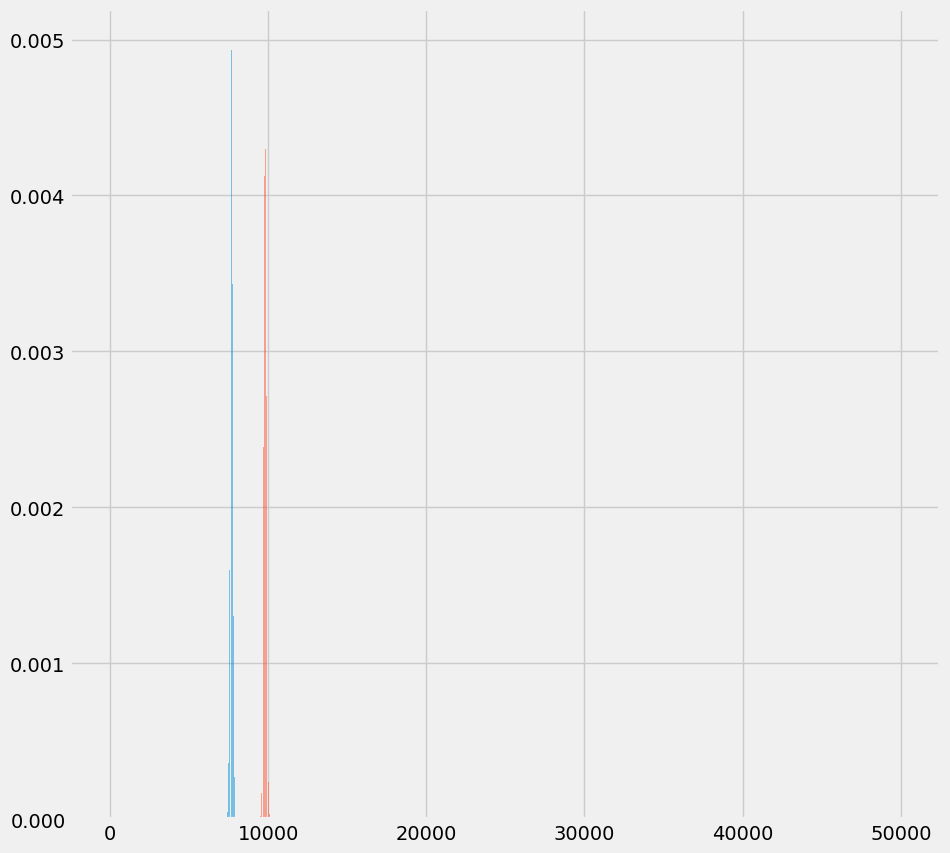

In [50]:
#plot

# Plotting area
fig, ax = plt.subplots(figsize = (10,10))

# We set different values for x
x = np.linspace(0,int(n), int(n) + 1)

# We plotted the results with pmf and alpha of 0.5.
ax.bar(x, test_binom.pmf(x), alpha = 0.5)
ax.bar(x, test_binom_mde.pmf(x), alpha = 0.5)

### Task 3 - Distribution Plot

We created a plot of the distribution of the diffence between the two samples and compared the results.

We can campare the two groups by plotting the distribution of the control group and calculating the probability of obtaining the result of our test group.

Text(0, 0.5, 'Probability')

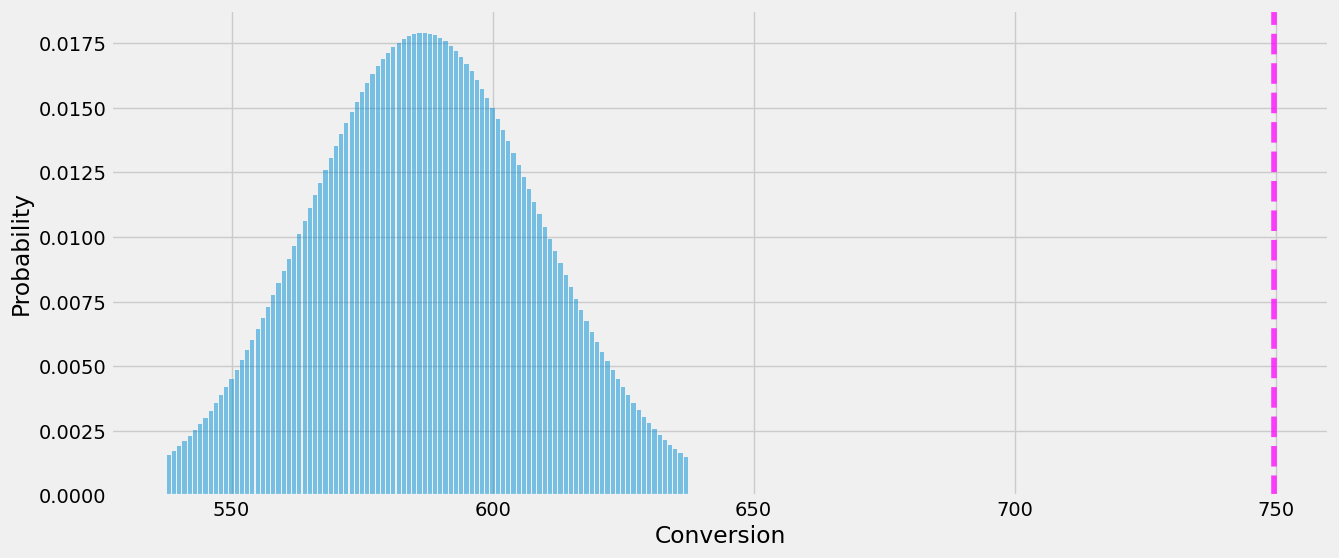

In [51]:
# Plot of the distribution of group A (Control)

# Plotting area
fig , ax = plt.subplots(figsize = (14,6))

# Test A
x = np.linspace(conversion_A - 49, conversion_A + 50, 100)
y = scs.binom(total_A, fee_A).pmf(x)


# Creates the vertical bar
ax.bar(x, y, alpha = 0.5)
ax.axvline(x = fee_B * total_A, c = 'magenta', alpha = 0.75, linestyle = '--')

# Labels

plt.xlabel('Conversion')
plt.ylabel('Probability')

Text(0, 0.5, 'Probability')

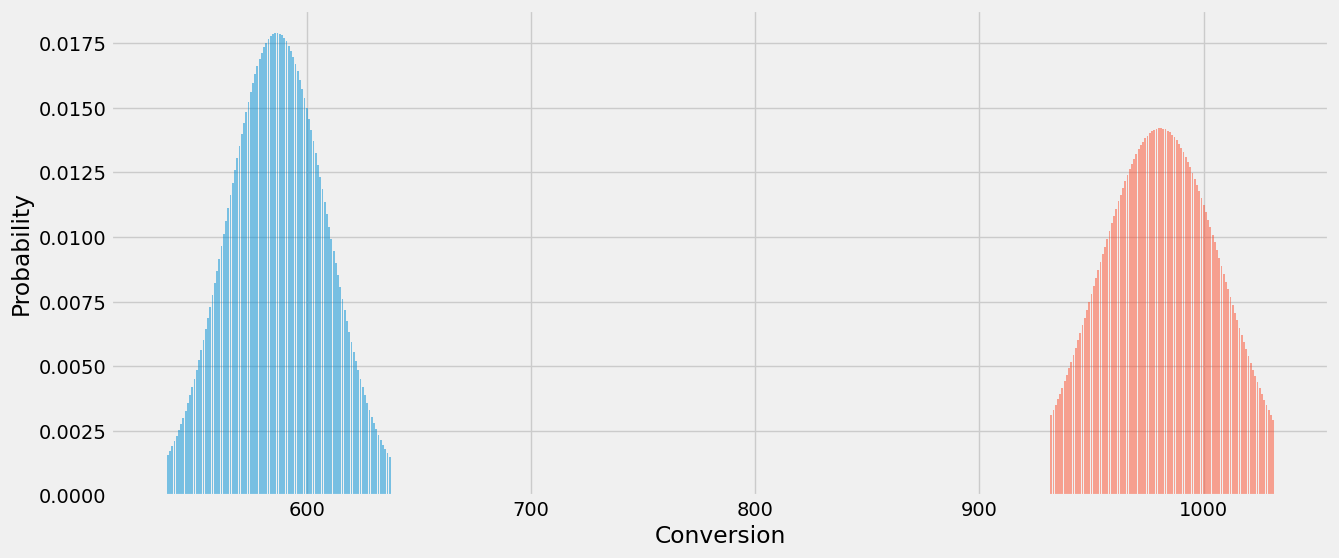

In [52]:
# Plot of the distribution of the two groups


# Plotting area
fig , ax = plt.subplots(figsize = (14,6))

# Graph of A
xA = np.linspace(conversion_A - 49, conversion_A + 50, 100)
yA = scs.binom(total_A, fee_A).pmf(xA)
ax.bar(xA, yA, alpha = 0.5)

# Graph of B
xB = np.linspace(conversion_B - 49, conversion_B + 50 , 100)
yB = scs.binom(total_B, fee_B).pmf(xB)
ax.bar(xB, yB, alpha = 0.5)

# Labels

plt.xlabel('Conversion')
plt.ylabel('Probability')

We can see that the test group converted more users than the control group.
We can also seet that the peak of the test group's results is lower than that of the control group.

But how do we interpret the difference in the probability peak ?

Instead, we should focus on the conversion rate so that we have a comparison of equivalent terms. To calculate this, we need to standardize the data and compare the probability of success, p, for each group.

In [53]:
# Adjusts the name of the variables

# Probabilities (fee of conversion)
p_A = fee_A
p_B = fee_B

# Number of conversion
N_A = 3821
N_B = 5000

In [54]:
# Standard error for the mean of both groups
SE_A = np.sqrt(p_A * (1 - p_A)) / np.sqrt(total_A)
SE_B = np.sqrt(p_B * (1 - p_A)) / np.sqrt(total_B)
print("SE_A :" , SE_A, '\n', "SE_B :",SE_B)

SE_A : 0.005833423432971666 
 SE_B : 0.005762965083466871


Text(0, 0.5, 'PDF - Probability Density Function')

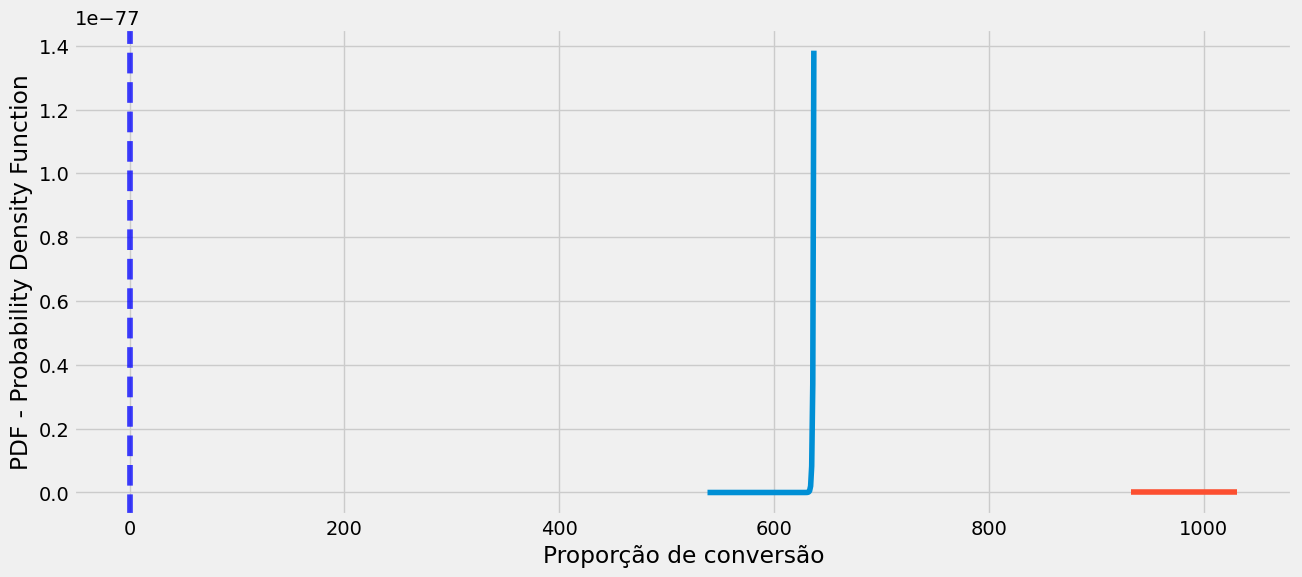

In [55]:
# Plot of the distributions of the null and alternative hypotheses

# Plotting area
fig, ax = plt.subplots(figsize = (14,6))

# Data for random variables
x = np.linspace(0, p_B - p_A, 100)

# Distribution of A
yA = scs.norm(p_A, SE_A).pdf(x)
ax.plot(xA, yA)
ax.axvline(x = p_A, c = 'blue', alpha = 0.5, linestyle = '--')

# Distribution of B
yB = scs.norm(p_B, SE_B).pdf(x)
ax.plot(xB, yB)
ax.axvline(x = p_B, c = 'blue', alpha = 0.5, linestyle = '--')

# Labels
plt.xlabel('Proporção de conversão')
plt.ylabel('PDF - Probability Density Function')

The solid lines represent the average conversion rate for each group.
The distance between the blue line and the red line is equal to the average difference between the control and test groups.

**Sum Variance**

Remember that the null hypothesis states that the difference in probability between the two groups is zero. Therefore, the mean for this normal distribution will be zero. The other property we will need for the normal distribution is the standard deviation or variance.

Note: Variance is the stantard deviation squared. The variance of the difference will depend on the variances of the probability for both groups.

### Verifying the null hypothesis and the alternative Hypothesis

Let's start by recalling the definition of the null hypothesis and the alternative hypothesis.

**The null hypothesis is the position that the change in design made for the test group would result in no change in the conversion rate.**

**The alternative hypothesis is the opposite position that the change in design for the test group would result in an improvement ( or reduction ) in the conversion rate.**

The null hypothesis will be a normal distribuition with a mean of zero and a standard deviation equal to the pooled standard error.



The alternative hypothesis has the same standard deviation as the null hypothesis, but the mean will be located at the difference in conversion rates, d_hat. This makes sense because we can calculate the difference in conversion rates directly from the data, but the normal distribution represents possible values that our experiment could have given us.

In [56]:
# Calculate the grouped probability
prob_grouped = (p_A * N_A + p_B * N_B) / (N_A + N_B)

In [57]:
# Calculating z
z = (p_B - p_A) / (prob_grouped * (1 - prob_grouped) * (1/N_A + 1 /N_B))**0.5
z

5.1827257006909795

In [58]:
# We check if z is greater than 1.64 ( signficance level of 0.05)
z > 1.64

True

In [59]:
# Function that returns the grouped probability for 2 samples
def prob_grouped_func(N_A, N_B, X_A, X_B):
    return (X_A + X_B) / (N_A + N_B)

In [60]:
# Function that returns the stand error grouped for 2 samples
def error_stand_grouped_func(N_A, N_B, X_A, X_B):
    p_hat = prob_grouped_func(N_A, N_B, X_A, X_B)
    SE = np.sqrt(p_hat * (1 - p_hat) * (1 / N_A + 1 / N_B))
    return SE

In [61]:
# Function the z-value for a given significance level
def z_val(sig_level = 0.05 , two_tailed = True):

    # Generate distribution for the z value
    z_dist = scs.norm()

    # We check whehter we shoudl both tails
    if two_tailed:
        sig_level = sig_level/2
        area = 1 - sig_level
    else:
        area = 1 - sig_level
    # value of z
    z = z_dist.ppf(area)
    return z

In [62]:
# I calculate the confidence interval
def confidence_interval(sample_mean = 0, sample_std = 1, sample_size = 1, sig_level = 0.05):

    #calculate the value of z
    z = z_val(sig_level)

    # Left and right limits
    left = sample_mean - z * sample_std / np.sqrt(sample_size)
    right = sample_mean + z * sample_std / np.sqrt(sample_size)

    return (left, right)

In [63]:
# Function thar calculates the two-tailed confidence interval
def plot_CI(ax,
            mu,
            s,
            sig_level = 0.05,
            color = 'grey'):
    # Calculates that confidence interval
    left, right = confidence_interval(sample_mean = mu, sample_std = s, sig_level = sig_level)

    # Includes the interval in the graph
    ax.axvline(left, c = color, linestyle='--', alpha = 0.5)
    ax.axvline(right, c = color, linestyle='--', alpha = 0.5)

In [64]:
# Funnction for plotting a normal distribution
def plot_norm_dist(ax,
                   mu,
                   std,
                   with_CI = False,
                   sig_level = 0.05,
                   label = None):
    # Generates values for the random variable x
    x = np.linspace(mu - 12 * std , mu + 12 * std, 1000)

    # Creates the normal distribution
    y = scs.norm(mu, std).pdf(x)

    #plot
    ax.plot(x, y, label = label)

    # if we have a confidence interval, we include it in the plot
    if with_CI:
        plot_CI(ax, mu, std, sig_level = sig_level)

Function for plotting the null hypothesis distribution where, if there is no real change, the distribuition of differences between the test and control groups will be normally distruted.

In [65]:
# function for plotting the distribution of H0
def plot_H0(ax, stderr):
    plot_norm_dist(ax, 0, stderr, label = "HO - Null Hypothese")
    plot_CI(ax, mu = 0 , s = stderr, sig_level = 0.05)

Function for plotting the alternative hypothesis distribuition where, if there is a real change, the distribution of differences between the test and control groups will be normally distributed and centered around d_hat

In [66]:
#Funcion to plotting the distribution H1
def plot_H1(ax, stderr, d_hat):
    plot_norm_dist(ax, d_hat, stderr, label = 'H1 - Alternative Hypothese')

In [67]:
# Function that fills between the upper limit of significance and the distribution for the alternative hypothesis
def show_area(ax, d_hat ,stderr, sig_level):
    
    # Confidence interval
    left, right, = confidence_interval(sample_mean=0, sample_std = stderr, sig_level = sig_level)
    
    # Values for x
    x = np.linspace(-12 * stderr, 12 * stderr, 1000 )
    
    # H0
    null = ab_dist(stderr, 'control')
    
    # H1
    alternative = ab_dist(stderr, d_hat,'test')
    
    # if the type of area is equal to power
    # We fill in between the upper significance limit and the distribution for the alternative hypothesis
    ax.fill_between(x, 0, alternative.pdf(x), color = 'green', alpha = 0.25, where = (x > right))
    ax.text(-3 * stderr,
            null.pdf(0),
            'power - {0:.3f}'.format(1 - alternative.cdf(right)),
           fontsize = 12, 
            ha = 'right',
            color = 'k'
           )

In [68]:
# Funct that returns a distribution object depending on the group type
def ab_dist(stderr, d_hat = 0, group_type = 'control'):
    
    # check the group type
    if group_type == 'control':
        sample_mean = 0
    elif group_type == 'test':
        sample_mean = d_hat
        
    # creates a normal distribution that depends of mean and the standard deviation
    dist = scs.norm(sample_mean, stderr)
    return dist

In [69]:
# Function that return the p-value
def p_val(N_A, N_B, p_A, p_B):
    return scs.binom(N_A, p_A).pmf(p_B * N_B)

In [70]:
# Function for plotting the A/B test analysis
def abplot_func(N_A,
                N_B,
                bcr,
                d_hat,
                sig_level = 0.05,
                show_p_value = False,
                show_legend = True):
    
    # Define the plotting area
    fig, ax = plt.subplots(figsize = (14, 8))
    
    # Sets parameter to find the grouped standard error
    X_A = bcr * N_A
    X_B = (bcr + d_hat) * N_B
    stderr = error_stand_grouped_func(N_A, N_B, X_A, X_B)
    
    # Plot of the distribution o the null and alternative hypotheses
    plot_H0(ax, stderr)
    plot_H1(ax, stderr, d_hat)
    
    # Define the extent of the plot area
    ax.set_xlim(-8 * stderr, 8 * stderr)
    
    # we adjust the chart and fill in the inner area.
    show_area(ax, d_hat, stderr, sig_level)
    
    # We show p-values based on distributions for the two groups
    if show_p_value:
        null = ab_dist(stderr, 'control')
        p_value = p_val(N_A, N_B, bcr, bcr + d_hat)
        ax.text(3 * stderr, null.pdf(0), 'p-Value = {0:.4f}'.format(p_value), fontsize = 14, ha = 'left')
        
    # Show legends
    if show_legend:
        plt.legend()
    
    plt.xlabel('d')
    plt.ylabel('PDF')
    plt.show()

Now that we understand the derivation of the combined standard error, we can simply plot the null and alternative hypotheses directly for future experiments. All we need to do is run the cell below.

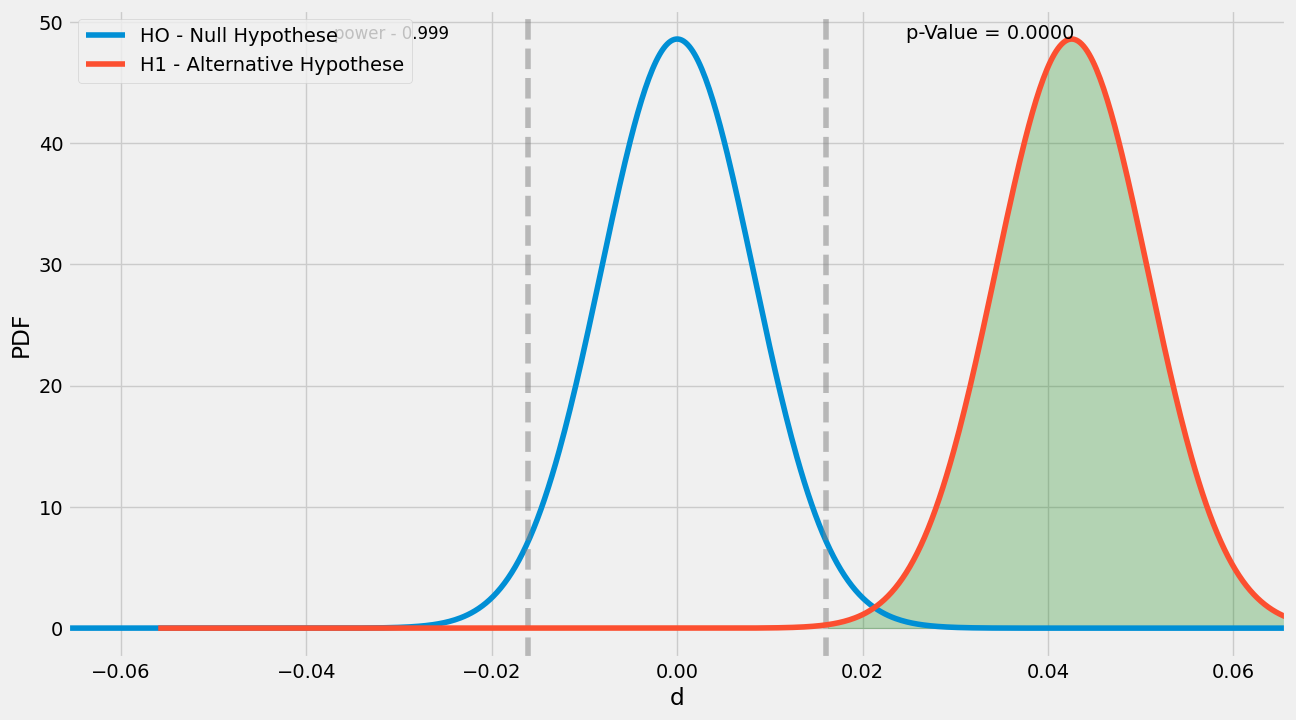

In [71]:
n = N_A + N_B
conversion_base = p_A  
d_hat = p_B - p_A
abplot_func(N_A, N_B, conversion_base, d_hat, show_p_value = True)

Visually, the graph for the null and alternative hypotheses is very similar to the other graphs above. Fortunately, the two curves have identical shapes, so we can simply compare the distance between the average of the two distributions. We can see that the alternative hypothesis curve suggests that the test group thas a higher conversion rate than the control group. This graph can also be used to directly determine statistical power.

### Task 4 - Calculating Statistical Power 
Statistical Power and Significante Level

It is easier to define statistical power and sifnificante level by first showing how they are represented in the null and alternative hypothesis graph. we can return a visualization of statistical power by adding the parameter show_power = True

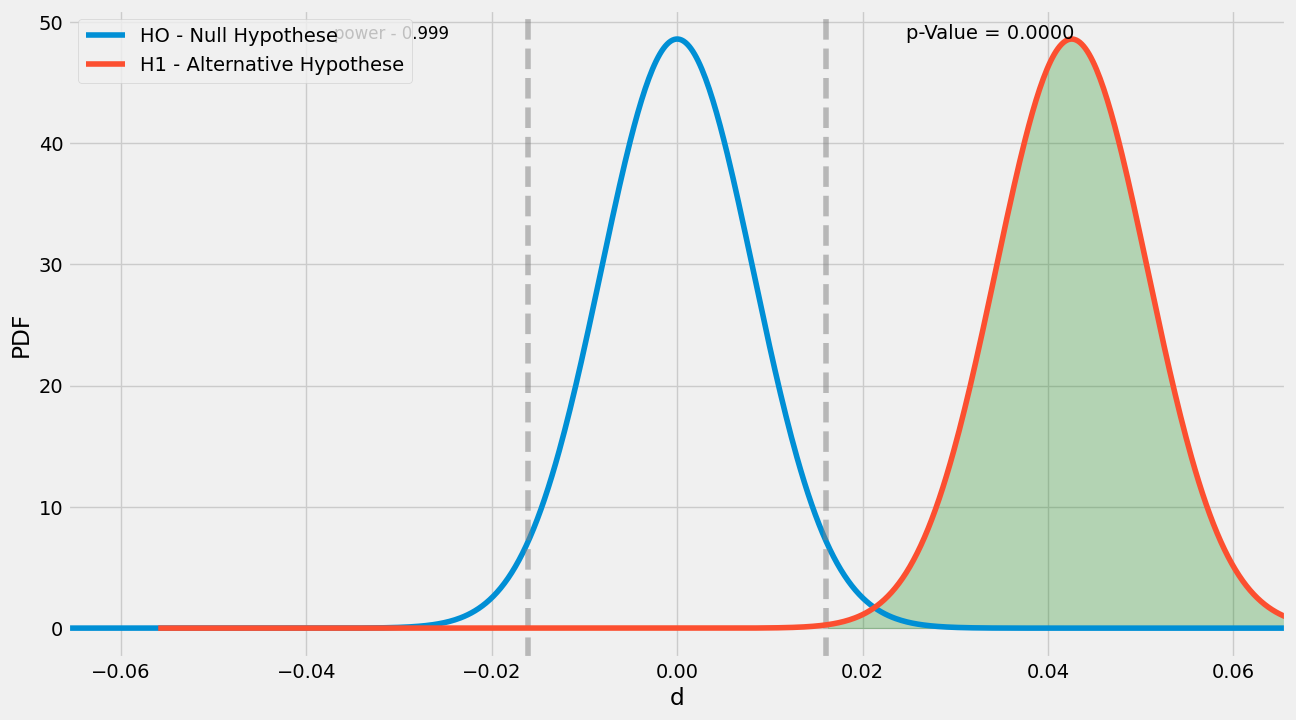

In [72]:
# Executes the function
abplot_func(N_A, N_B, conversion_base, d_hat, show_p_value=True)

The area shaded in green represents the statistical power, and the calculated value for the power is also displayed in the graph. The gray dashed lines in the graph above represent the confidence interval (95% for the graph above) for the null hypothesis. The Statistical power is calculated by finding ghe area under the alternative hypothesis distribution and outside the confidence interval of the null hypothesis.

After running our experiment, we obtain a resulting conversion rate for both groups. if we calculate the difference between the conversion rates, we end up with a result, the difference or effect of the web page design change, not showing user reviews. Our task is to de
termine which population this result came from, the null hypothesis or the alternative hypothesis.

The area under the alternative hypothesis curve is equal to 1. if the alternative design ( without evalutations is actuallly better, the power is the probability that we will accept the alternative hypothesis and reject the null hypothesis, and is equal to the are shaded in greeen (true positive). The opposite area under the alternative curve is the probability that we will not reject the null hypothesis and reject the alternative hypothesis (false negative). This is known as beta in A/B testing or hypothesis testing and is shown below.

If the null hypothesis is true and there really is no difference between the control and test groups, the significance level is the probability that we will reject the null hypothesis (false positive). A false positive is when we mistakenly conclude that the new design is better. This value is low because whe want to limit this probability.

Often, a problem will be given with a desired confidence level instead of the sifnificance level. A typical confidence level of 95% for an A/B test corresponds to a significance level of 0.05.

Experiments are typically set up for a minimum desired power of 80%. If our new design is truly better, we want our experiment to show that there is at least an 80% chance that this is the case. We know htat if we increase the sample size for each group, we will decrease the combined variance for our null and alternative hypotheses. This will make our distributions much narrower and may increase statistical power. Let's take a look at how sample size will directly affect our results.

### Task 5 - Influence of Sample Size on A/B Testing

Our curves for the null and alternative hypotheses have become narrower, and more of the area under the alternative curve is located to the right of the gray dashed line. The result for power is greater than 0.80 and meets our statistical power benchmark. We can now say that our results are statiscally signicant.

The next problem we must address is determining the minimum sample size we will need for the experiment. This is useful to know because it is directly related to how quickly we can complete the experiments and provide statistically significant results to the business area.

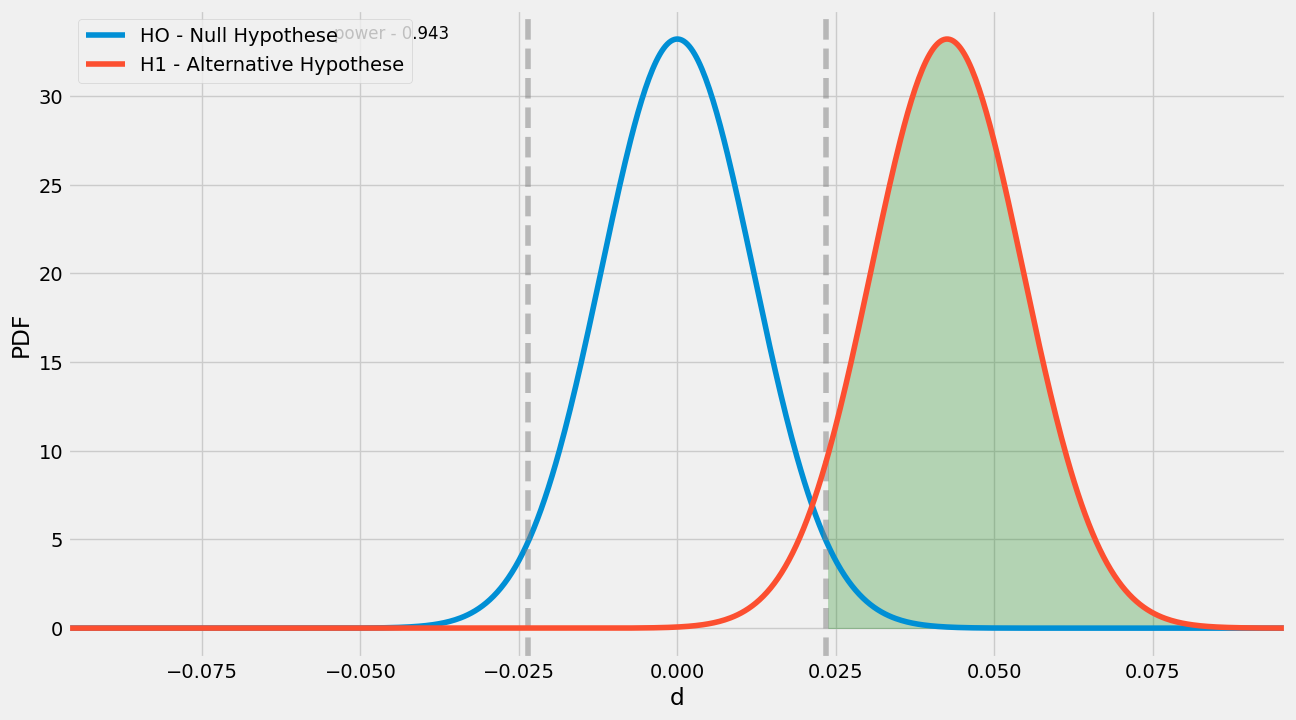

In [73]:
abplot_func(2000,2000, conversion_base, d_hat)

We have the baseline conversion rate and the minimum detectable effect, which is the minimum difference between the control and test group that the business team will determine is worth the investment of making the design change in the first place.

In [74]:
# Function to include the value z in the plot

def zplot(area = 0.95, two_tailed = True, align_right = True):
    
    # Creates the plotting area
    fig = plt.figure(figsize=(12,6))
    ax = fig.subplots()
    
    # Creates the normal distribution
    norm = scs.norm()
    
    # Creates the data points for the plot
    x = np.linspace(-5,5, 1000)
    y = norm.pdf(x)
    ax.plot(x,y)
    
    # Code for filling in areas for bidirectional testing
    
    if two_tailed:
        left = norm.ppf(0.5 - area / 2)
        right = norm.ppf(0.5 + area / 2)
        ax.vlines(right, 0, norm.pdf(right), color = 'grey', linestyle = '--')
        ax.vlines(left, 0, norm.pdf(left), color = 'grey', linestyle = '--')

        ax.fill_between(x, 0, y, color = 'grey', alpha = 0.25, where = (x > left) & (x < right))
        
        plt.xlabel('z')
        plt.ylabel('PDF')
        plt.text(left, norm.pdf(left), "z = {0:.3f}".format(left), 
                 fontsize = 12, 
                 rotation = 90, 
                 va = "bottom", 
                 ha = "right")
        plt.text(right, norm.pdf(right), "z = {0:.3f}".format(right), 
                 fontsize = 12, 
                 rotation = 90, 
                 va = "bottom", 
                 ha = "left")
        
    # For single-tail testing
    else:
        #Right alignment
        if align_right:
            left = norm.ppf(1-area)
            ax.vlines(left, 0, norm.pdf(left), color = 'grey', linestyle = '--')
            ax.fill_between(x,0,y, color = 'grey', alpha = 0.25, where = x > left)
            plt.text(left, norm.pdf(left), "z = {0:3f}".format(left),
                     fontsize = 12,
                     rotation = 90,
                     va = 'bottom',
                     ha = 'right')
        # Left alignment
        else:
            right = norm.ppf(1-area)
            ax.vlines(left, 0, norm.pdf(right), color = 'grey', linestyle = '--')
            ax.fill_between(x,0,y, color = 'grey', alpha = 0.25, where = x > left)
            plt.text(right, norm.pdf(right), "z = {0:3f}".format(right),
                     fontsize = 12,
                     rotation = 90,
                     va = 'bottom',
                     ha = 'right')
            
            # We include text in the plot
            plt.text(0,0.1, "Shaded Area = {0:.3f}".format(area), fontsize = 12, ha = 'center')
            
            #labels
            plt.xlabel('z')
            plt.ylabel('PDF')
            
            plt.show()
    

In [75]:
# Função para incluir o valor z no plot
def zplot(area = 0.95, two_tailed = True, align_right = False):

    # Cria a área de plotagem
    fig = plt.figure(figsize = (12, 6))
    ax = fig.subplots()
    
    # Cria a distribuição normal
    norm = scs.norm()
    
    # Cria os pontos de dados para o plot
    x = np.linspace(-5, 5, 1000)
    y = norm.pdf(x)

    ax.plot(x, y)

    # Código para preencher áreas para testes bidirecionais
    if two_tailed:
        left = norm.ppf(0.5 - area / 2)
        right = norm.ppf(0.5 + area / 2)
        ax.vlines(right, 0, norm.pdf(right), color = 'grey', linestyle = '--')
        ax.vlines(left, 0, norm.pdf(left), color = 'grey', linestyle = '--')

        ax.fill_between(x, 0, y, color = 'grey', alpha = 0.25, where = (x > left) & (x < right))
        
        plt.xlabel('z')
        plt.ylabel('PDF')
        plt.text(left, norm.pdf(left), "z = {0:.3f}".format(left), 
                 fontsize = 12, 
                 rotation = 90, 
                 va = "bottom", 
                 ha = "right")
        plt.text(right, norm.pdf(right), "z = {0:.3f}".format(right), 
                 fontsize = 12, 
                 rotation = 90, 
                 va = "bottom", 
                 ha = "left")
    
    # Para testes de uma cauda
    else:
        # Alinhamento à direita
        if align_right:
            left = norm.ppf(1-area)
            ax.vlines(left, 0, norm.pdf(left), color = 'grey', linestyle = '--')
            ax.fill_between(x, 0, y, color = 'grey', alpha = 0.25, where = x > left)
            plt.text(left, norm.pdf(left), "z = {0:.3f}".format(left), 
                     fontsize = 12, 
                     rotation = 90, 
                     va = "bottom", 
                     ha = "right")
        
        # Alinhamento à esquerda
        else:
            right = norm.ppf(area)
            ax.vlines(right, 0, norm.pdf(right), color = 'grey', linestyle = '--')
            ax.fill_between(x, 0, y, color = 'grey', alpha = 0.25, where = x < right)
            plt.text(right, norm.pdf(right), "z = {0:.3f}".format(right), 
                     fontsize = 12, 
                     rotation = 90, 
                     va = "bottom", 
                     ha = "left")

    # Incluímos texto no plot
    plt.text(0, 0.1, "Área Sombreada = {0:.3f}".format(area), fontsize = 12, ha = 'center')
    
    # Labels
    plt.xlabel('z')
    plt.ylabel('PDF')

    plt.show()

In [76]:
# Print the value of z
print(z)
print(z_val(sig_level = 0.05, two_tailed = False))
print(z > z_val(sig_level = 0.05, two_tailed = False))

5.1827257006909795
1.6448536269514722
True


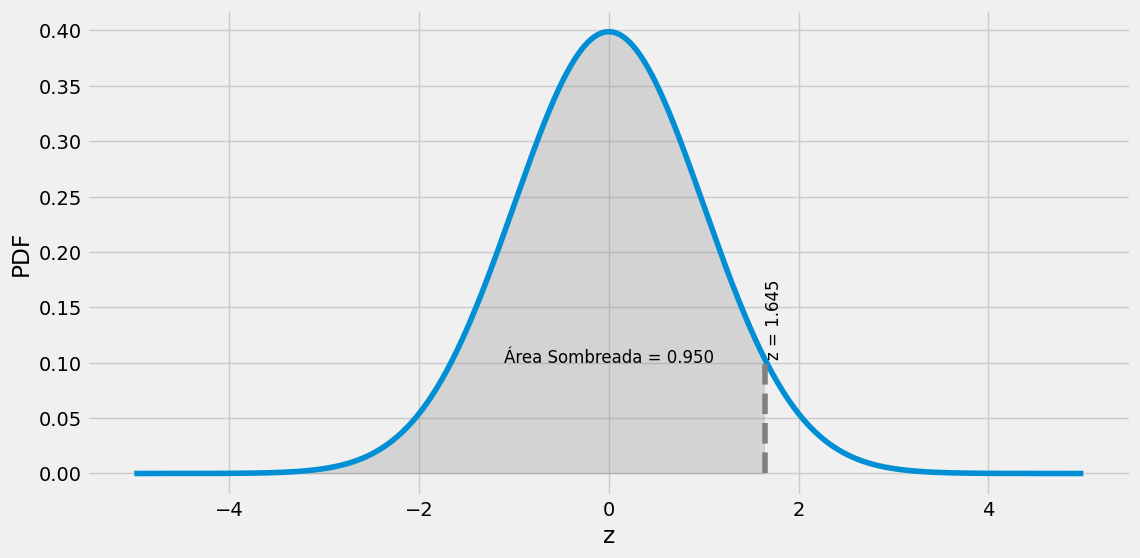

In [77]:
# Plot of z
zplot(area = 0.95, two_tailed = False, align_right = False)

Here is the python code that performs the same calculation for the minimum sample size:

In [78]:
# We calculate the values of z alpha and beta
sig_level = 0.05
beta = 0.2
k = N_A/N_B
standard_norm = scs.norm(0,1)
Z_beta = standard_norm.ppf(1-beta)
Z_alpha = standard_norm.ppf(1-sig_level)
print(Z_beta)
print(Z_alpha)


0.8416212335729143
1.6448536269514722


Let's calculate the minimum sample size required

In [79]:
# Function to find the minimum sampla size
def calculate_mininum_sample_size(N_A,
                                  N_B,
                                  p_A,
                                  p_B,
                                  power= 0.8,
                                  sig_level = 0.05,
                                  two_sided = False):
    k = N_A/N_B
    
    # Normal distribution to determine z-values
    standard_norm = scs.norm(0,1)
    
    # we found the value of z for statistical power
    Z_beta = standard_norm.ppf(power)
    
    # We found z alpha
    if two_sided == True:
        Z_alpha = standard_norm.ppf(1-sig_level/2)
    else:
        Z_alpha = standard_norm.ppf(1-sig_level)
    
    # Grouped probabitlity
    pooled_prob = (p_A + p_B) / 2
    
    # Minimum sample size
    min_N = (2 * pooled_prob * (1 - pooled_prob) * (Z_beta + Z_alpha)**2 / minimum_effect**2)
    
    return min_N
    

In [80]:
# we calculate the minimum sample size with two_sided = True
calculate_mininum_sample_size(N_A, N_B, p_A, p_B, power = 0.8, sig_level=0.05, two_sided=True)

1249.8068972849476

In [81]:
# we calculate the minimum sample size with two_sided = False
calculate_mininum_sample_size(N_A, N_B, p_A, p_B, power = 0.8, sig_level=0.05, two_sided=False)

984.4720435225323

Now let's calculate the minimum sample size considering our baseline


In [82]:
conversion_base + minimum_effect

0.1962

In [83]:
# Calculates the grouped probability
grouped_probability = (conversion_base + conversion_base + minimum_effect) / 2
grouped_probability


0.1749123527872285

In [84]:
# Sum of alpha and beta Z
Z_beta + Z_alpha

2.4864748605243863

In [85]:
# Minimum sample size for baseline
min_N = ( 2 * grouped_probability * (1- grouped_probability) * (Z_beta + Z_alpha) **2 / minimum_effect**2)
min_N

984.4720435225323

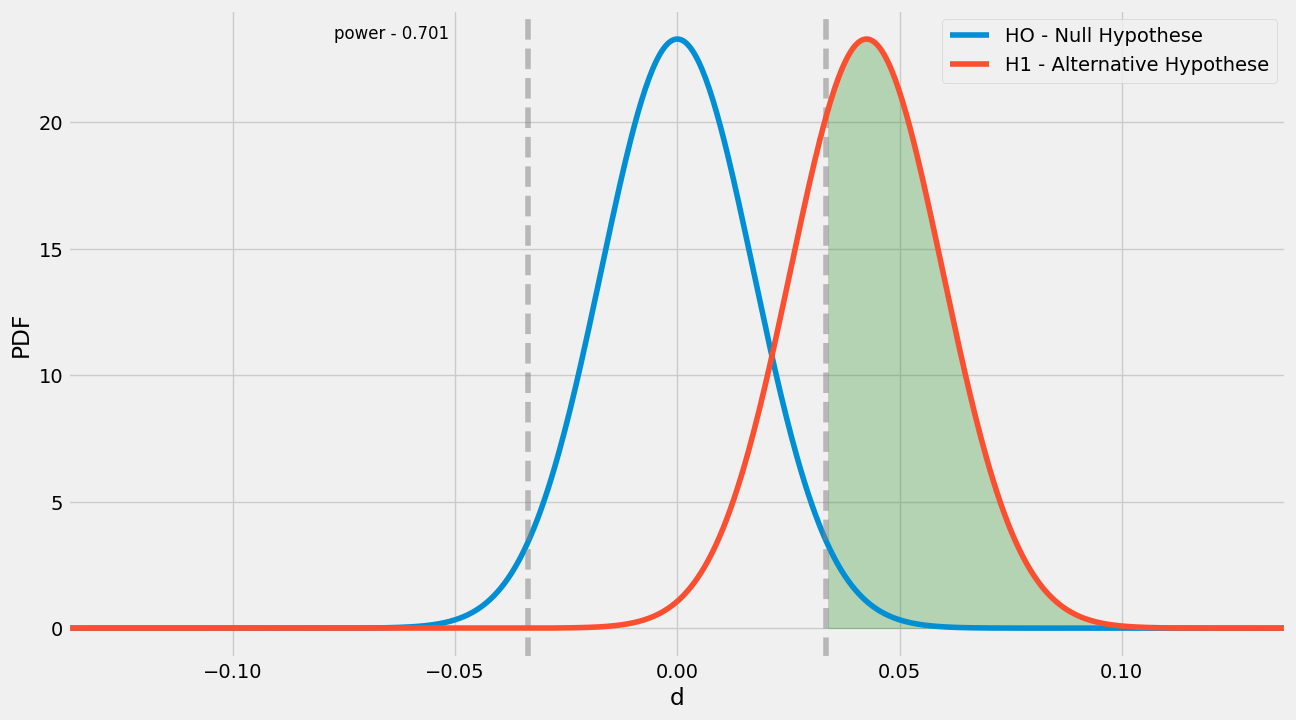

In [86]:
# Peforms the function for 984 samples
abplot_func(N_A = 984, 
            N_B = 984, 
            bcr = p_A, 
            d_hat = p_B - p_A, 
            sig_level = 0.05, 
            show_p_value = False, 
            show_legend = True)

Statistical power for the calculated sample size.

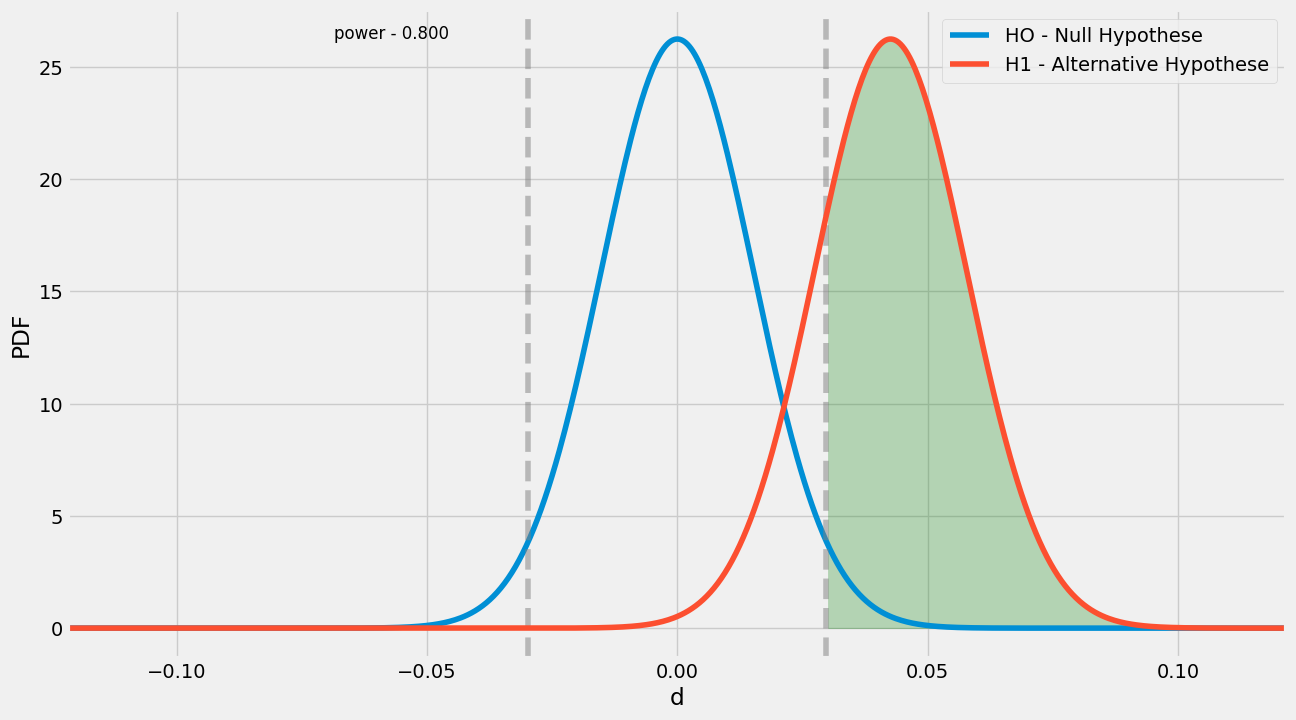

In [87]:
abplot_func(N_A = 1249, 
            N_B = 1249, 
            bcr = p_A, 
            d_hat = p_B - p_A, 
            sig_level = 0.05, 
            show_p_value = False, 
            show_legend = True)

### Conclusion and Final Considerations

The power calculated for this sample size was approximately 0.80. Therefore, to claim that changing the page by removing user reviews actually increased the conversion rate, we need at least 1249 samples

For our example, with 1249 samples, we can say that yes. removing user reviews from the page increases the conversion rate.